In [1]:
import os
import cv2 as cv
from glob import glob
import matplotlib.pyplot as plt
import numpy as np

from Generator import *

=== DIV2K Dataset Analysis ===

Training images: 800
Validation images: 100
Total images: 900

Size range:
  Height: 768 - 2040px
  Width: 1140 - 2040px

Sample images:


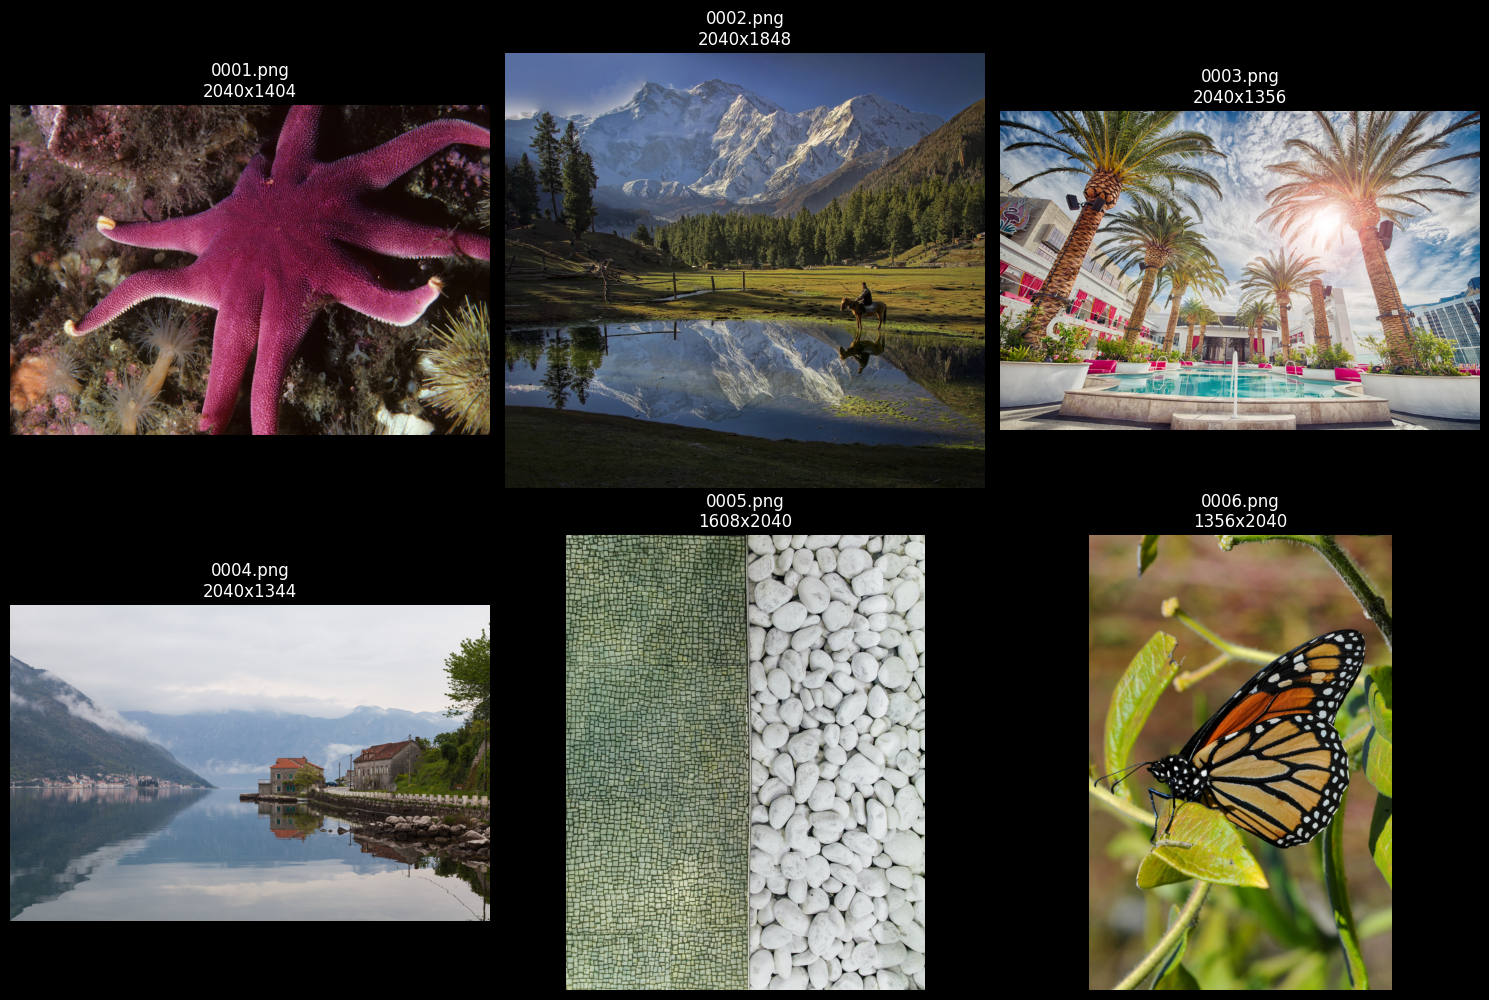

In [2]:
IMAGE_SIZE = 256

DIV2K_PATH = "./datasets/DIV2K"
TRAIN_IMAGES = glob(os.path.join(DIV2K_PATH, "DIV2K_train_HR", "*.png"))
VAL_IMAGES = glob(os.path.join(DIV2K_PATH, "DIV2K_valid_HR", "*.png"))

# Dataset Analysis
print("=== DIV2K Dataset Analysis ===\n")

# Count images
print(f"Training images: {len(TRAIN_IMAGES)}")
print(f"Validation images: {len(VAL_IMAGES)}")
print(f"Total images: {len(TRAIN_IMAGES) + len(VAL_IMAGES)}\n")

if len(TRAIN_IMAGES) == 0:
    print("WARNING: No training images found!")
else:
    # Analyze image dimensions
    train_sizes = []
    for img_path in TRAIN_IMAGES[:50]:  # Sample first 50 for speed
        img = cv.imread(img_path)
        if img is not None:
            train_sizes.append(img.shape[:2])  # (height, width)

    heights, widths = zip(*train_sizes)

    print(f"Size range:")
    print(f"  Height: {min(heights)} - {max(heights)}px")
    print(f"  Width: {min(widths)} - {max(widths)}px\n")

# Display sample images
print("Sample images:")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, ax in enumerate(axes.flat):
    if i < len(TRAIN_IMAGES):
        img = cv.imread(TRAIN_IMAGES[i])
        if img is not None:
            img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
            ax.imshow(img_rgb)
            ax.set_title(f"{os.path.basename(TRAIN_IMAGES[i])}\n{img.shape[1]}x{img.shape[0]}")
            ax.axis('off')

plt.tight_layout()
plt.show()


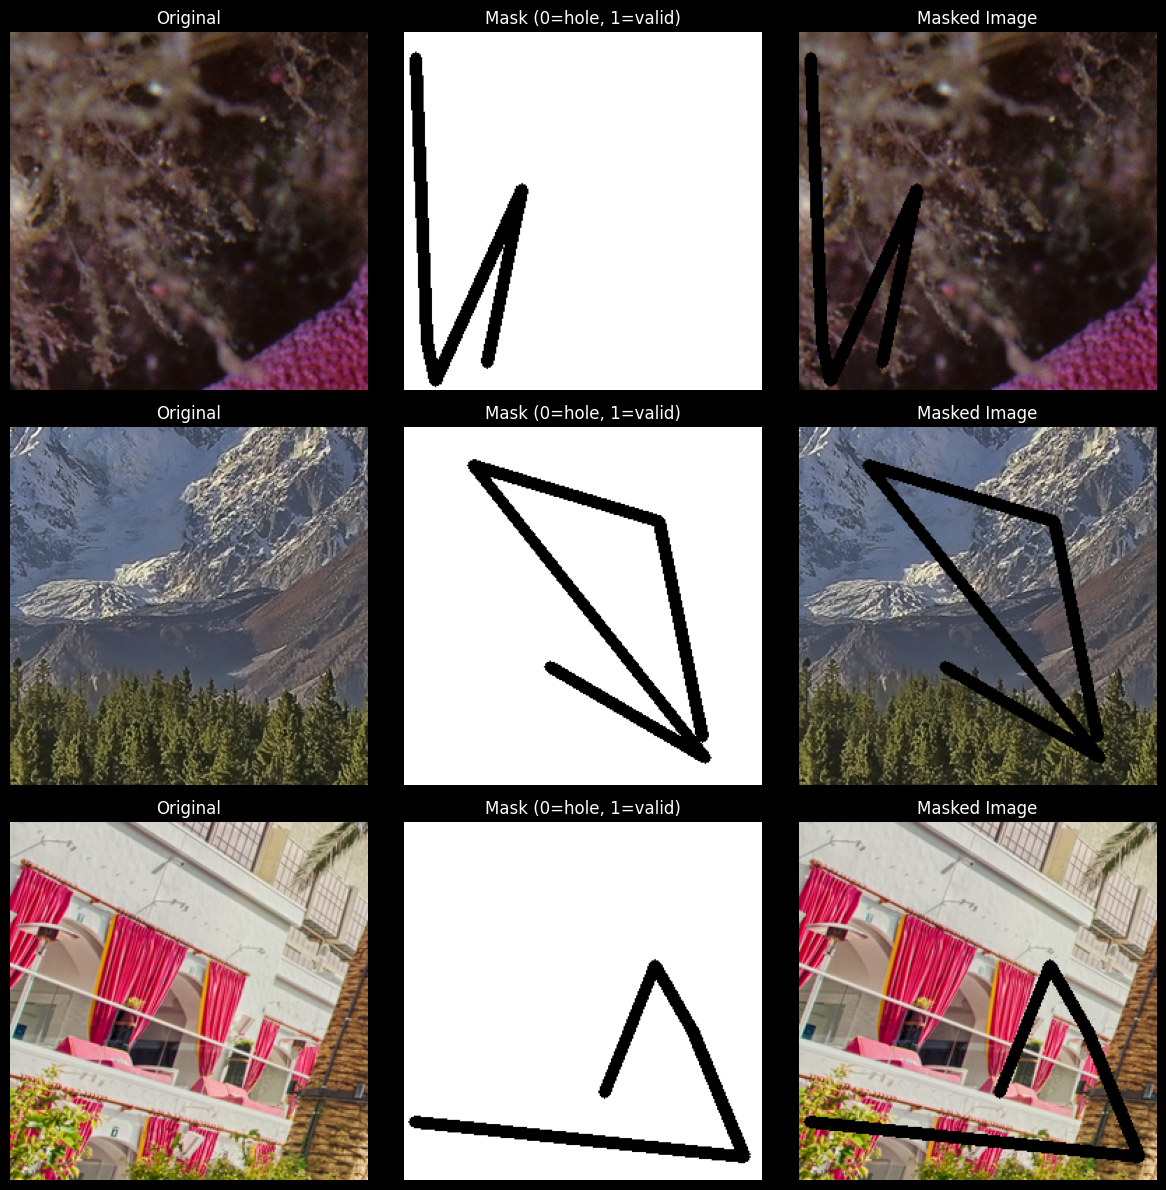

In [3]:
# Generate and display masks for sample images
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):
    if i < len(TRAIN_IMAGES):
        # Load image
        img = cv.imread(TRAIN_IMAGES[i])
        img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

        img_rgb = random_crop(img_rgb, IMAGE_SIZE)

        # Generate mask
        mask = generate_random_mask(IMAGE_SIZE, IMAGE_SIZE, num_strokes=np.random.randint(4, 5),
                                    thickness=np.random.randint(7, 9))

        # Apply mask to image
        masked_img = apply_mask(img_rgb, mask)

        # Display: original, mask, masked image, mask overlay
        axes[i, 0].imshow(img_rgb)
        axes[i, 0].set_title('Original')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title('Mask (0=hole, 1=valid)')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(masked_img)
        axes[i, 2].set_title('Masked Image')
        axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

✓ Random mode: picking from 800 images
Dataset length: 10

Testing same index twice (should show completely different samples):

Call 1:
  Original: torch.Size([3, 256, 256]) [0.000, 1.000]
  Masked:   torch.Size([3, 256, 256]) [0.000, 1.000]
  Mask:     torch.Size([1, 256, 256]) [0.000, 1.000]
  Mask sum: 60220

Call 2:
  Original: torch.Size([3, 256, 256]) [0.000, 1.000]
  Masked:   torch.Size([3, 256, 256]) [0.000, 1.000]
  Mask:     torch.Size([1, 256, 256]) [0.000, 1.000]
  Mask sum: 61231


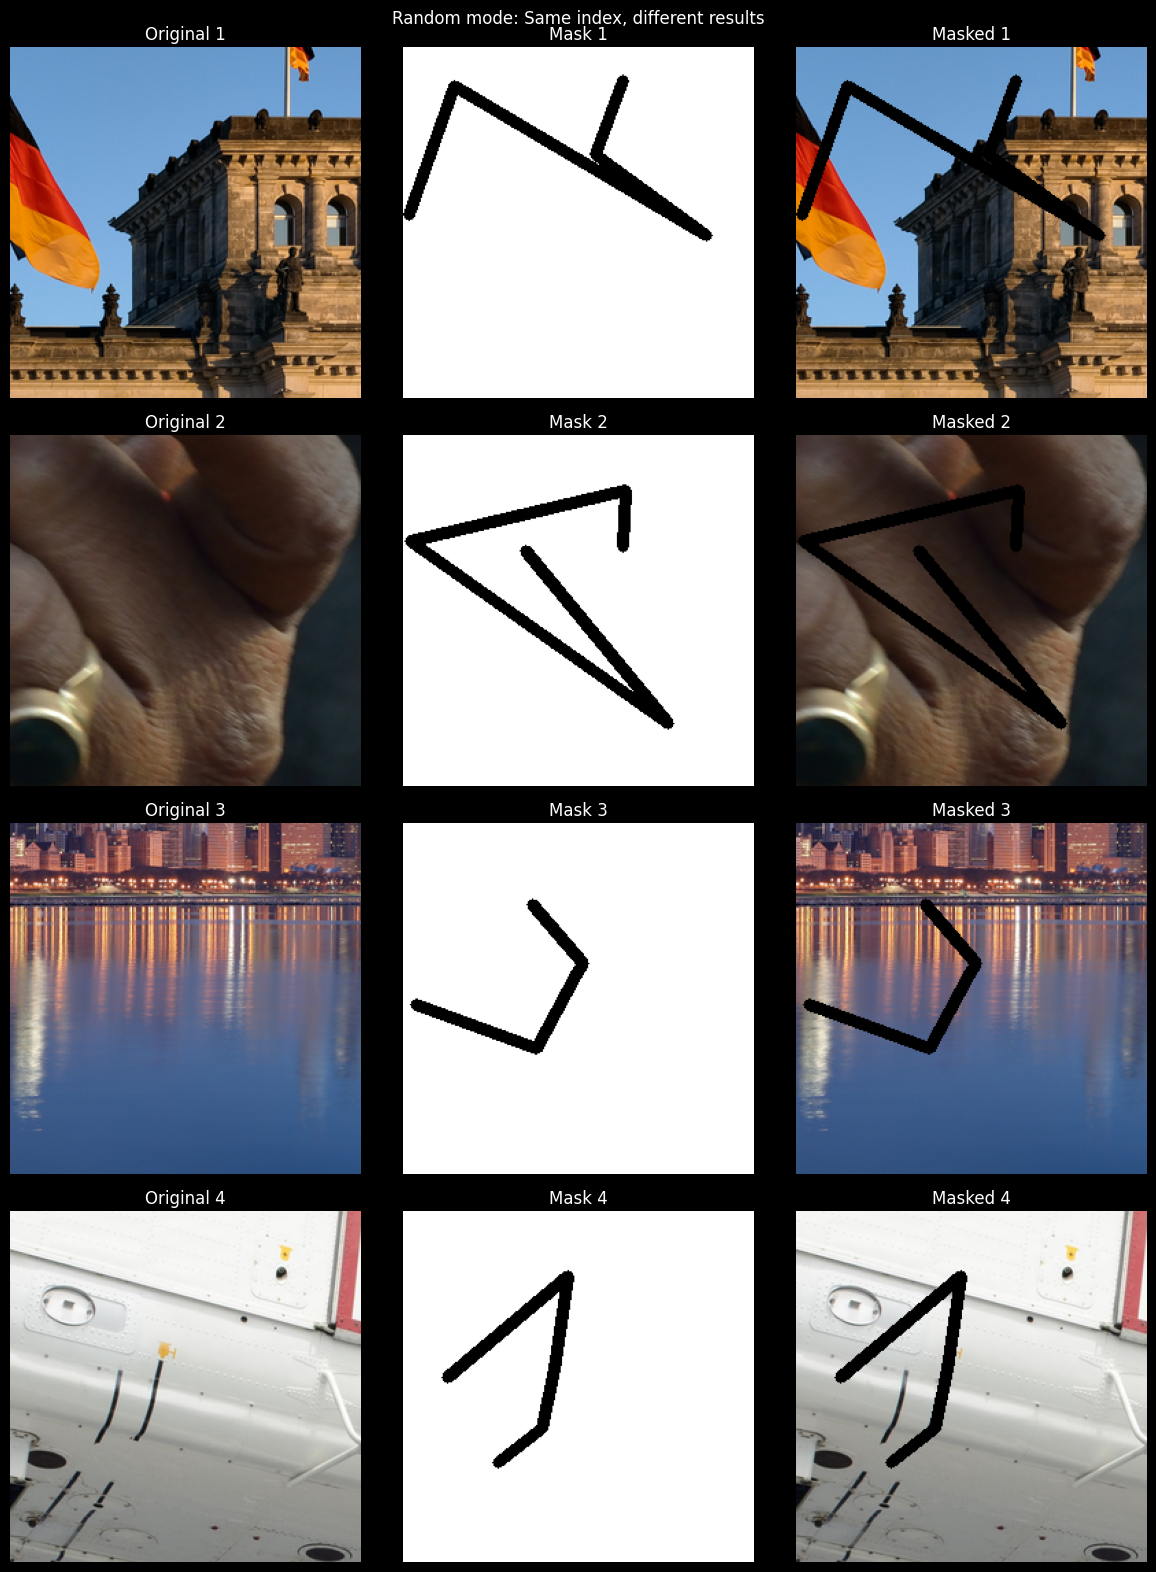

In [4]:
from Model import InpaintingDataset
import torch

DATASET_PATH_TRAIN = "datasets/DIV2K/DIV2K_train_HR"
DATASET_PATH_TEST = "datasets/DIV2K/DIV2K_valid_HR"

dataset_train = InpaintingDataset(
    image_dir=DATASET_PATH_TRAIN,
    checkpoint_dir="checkpoints/random",
    length=10,
    image_size=256,
    num_strokes=(4, 5),
    thickness=(7, 9),
    mode='random'
)

print(f"Dataset length: {len(dataset_train)}")
print("\nTesting same index twice (should show completely different samples):")

for i in range(2):
    masked_img, mask, original_img = dataset_train[0]
    print(f"\nCall {i + 1}:")
    print(f"  Original: {original_img.shape} [{original_img.min():.3f}, {original_img.max():.3f}]")
    print(f"  Masked:   {masked_img.shape} [{masked_img.min():.3f}, {masked_img.max():.3f}]")
    print(f"  Mask:     {mask.shape} [{mask.min():.3f}, {mask.max():.3f}]")
    print(f"  Mask sum: {mask.sum().item():.0f}")

# Visualize multiple samples
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for i in range(4):
    masked_img, mask, original_img = dataset_train[0]

    axes[i, 0].imshow(original_img.permute(1, 2, 0))
    axes[i, 0].set_title(f"Original {i + 1}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask[0], cmap='gray')
    axes[i, 1].set_title(f"Mask {i + 1}")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(masked_img.permute(1, 2, 0))
    axes[i, 2].set_title(f"Masked {i + 1}")
    axes[i, 2].axis('off')

plt.suptitle("Random mode: Same index, different results")
plt.tight_layout()
plt.show()

In [6]:
import torchinfo
from Model import UNetInpainting
import torch

batch_size = 1

model = UNetInpainting()

# Create dummy input and mask
dummy_input = torch.randn(batch_size, 3, IMAGE_SIZE, IMAGE_SIZE)
dummy_mask = torch.ones(batch_size, 1, IMAGE_SIZE, IMAGE_SIZE)

torchinfo.summary(
    model,
    input_data=[dummy_input, dummy_mask],
    verbose=1,
    depth=5
)

Layer (type:depth-idx)                   Output Shape              Param #
UNetInpainting                           [1, 3, 256, 256]          --
├─PartialBlock: 1-1                      [1, 32, 256, 256]         --
│    └─PartialConv2d: 2-1                [1, 32, 256, 256]         --
│    │    └─Conv2d: 3-1                  [1, 32, 256, 256]         896
│    └─BatchNorm2d: 2-2                  [1, 32, 256, 256]         64
│    └─ReLU: 2-3                         [1, 32, 256, 256]         --
├─PartialBlock: 1-2                      [1, 64, 128, 128]         --
│    └─PartialConv2d: 2-4                [1, 64, 128, 128]         --
│    │    └─Conv2d: 3-2                  [1, 64, 128, 128]         18,496
│    └─BatchNorm2d: 2-5                  [1, 64, 128, 128]         128
│    └─ReLU: 2-6                         [1, 64, 128, 128]         --
├─PartialBlock: 1-3                      [1, 128, 64, 64]          --
│    └─PartialConv2d: 2-7                [1, 128, 64, 64]          --
│    │   

Layer (type:depth-idx)                   Output Shape              Param #
UNetInpainting                           [1, 3, 256, 256]          --
├─PartialBlock: 1-1                      [1, 32, 256, 256]         --
│    └─PartialConv2d: 2-1                [1, 32, 256, 256]         --
│    │    └─Conv2d: 3-1                  [1, 32, 256, 256]         896
│    └─BatchNorm2d: 2-2                  [1, 32, 256, 256]         64
│    └─ReLU: 2-3                         [1, 32, 256, 256]         --
├─PartialBlock: 1-2                      [1, 64, 128, 128]         --
│    └─PartialConv2d: 2-4                [1, 64, 128, 128]         --
│    │    └─Conv2d: 3-2                  [1, 64, 128, 128]         18,496
│    └─BatchNorm2d: 2-5                  [1, 64, 128, 128]         128
│    └─ReLU: 2-6                         [1, 64, 128, 128]         --
├─PartialBlock: 1-3                      [1, 128, 64, 64]          --
│    └─PartialConv2d: 2-7                [1, 128, 64, 64]          --
│    │   